Vi revisitar det här fina AirBnb-setet för att se vad vi kan åstadkomma med hjälp av neurala nätverk! 

In [ ]:
# Vi vill veta vad vi kan göra för analys baserat på text-variablerna i datasetet, i synnerhet description.

Ursprunglig storlek: 4955 rader
Efter rensning: 3030 rader kvar
Pris: 120 → 3905 SEK (medel 1362)
Train: 2424, Test: 606

Bygger TF-IDF-vektorer...
  name                     : 100 features (max 100)
  description              : 200 features (max 200)
  amenities                : 100 features (max 100)
  neighborhood_overview    :  50 features (max 50)
  host_about               :  50 features (max 50)

Final feature matrix:
  Train: (2424, 500)
  Test:  (606, 500)
  Totalt 500 features (bara text)

Modell — antal parametrar: 74,497
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 1340.2087 - mae: 1340.2087 - val_loss: 1160.3088 - val_mae: 1160.3088
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 786.1448 - mae: 786.1448 - val_loss: 616.9075 - val_mae: 616.9075
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 619.7567 - mae: 619.7567 - val_loss: 585.3389 - val_mae: 585.3389
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 587.3717 - mae: 587.371

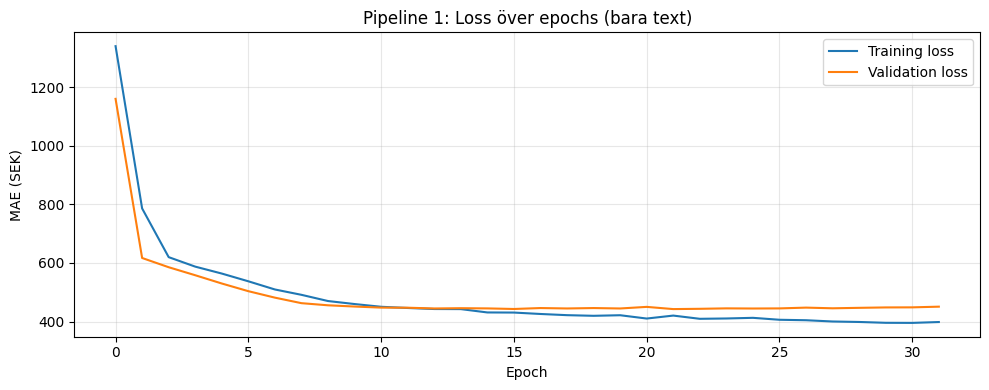

In [2]:
# ============================================================
# PIPELINE 1: BARA TEXT
# Förbehandling: TF-IDF på 5 textfält
# Modell: Sequential (Iris-stil)
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt

# ============================================================
# STEG 1: Ladda data
# ============================================================
df = pd.read_csv("data/airbnb_listings_stockholm_detailed.csv")
print(f"Ursprunglig storlek: {len(df)} rader")

target = "price"
text_cols = ["name", "description", "amenities",
             "neighborhood_overview", "host_about"]

# ============================================================
# STEG 2: Rensa pris
# ============================================================
df[target] = (
    df[target].astype(str)
              .str.replace(r"[\$,]", "", regex=True)
              .str.strip()
              .replace("", np.nan)
              .astype(float)
)
df = df.dropna(subset=[target])

# ============================================================
# STEG 3: Rensa textfält (NaN → "okänt", ta bort unicode)
# ============================================================
for c in text_cols:
    df[c] = (
        df[c]
        .fillna("okänt")
        .astype(str)
        .str.strip()
        .apply(lambda s: s.encode("latin-1", errors="ignore").decode("latin-1"))
        .replace("", "okänt")
        .replace("nan", "okänt")
    )

# ============================================================
# STEG 4: Stryp pris-outliers
# ============================================================
df = df[(df[target] >= 10) & (df[target] <= df[target].quantile(0.95))]

print(f"Efter rensning: {len(df)} rader kvar")
print(f"Pris: {df[target].min():.0f} → {df[target].max():.0f} SEK (medel {df[target].mean():.0f})")

# ============================================================
# STEG 5: Train/test split
# ============================================================
y = df[target].values.astype("float32")

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_df)}, Test: {len(X_test_df)}")

# ============================================================
# STEG 6: TF-IDF på varje textfält
# ============================================================
print("\nBygger TF-IDF-vektorer...")

tfidf_settings = {
    "name":                  100,
    "description":           200,
    "amenities":             100,
    "neighborhood_overview": 50,
    "host_about":            50,
}

tfidf_vectorizers = {}
tfidf_train = []
tfidf_test = []

for col, max_feat in tfidf_settings.items():
    tfidf = TfidfVectorizer(
        max_features=max_feat,
        stop_words="english",
        lowercase=True,
        min_df=5,
        ngram_range=(1, 1))
    
    train_vec = tfidf.fit_transform(X_train_df[col].values)
    test_vec  = tfidf.transform(X_test_df[col].values)
    
    tfidf_vectorizers[col] = tfidf
    tfidf_train.append(train_vec)
    tfidf_test.append(test_vec)
    print(f"  {col:25s}: {train_vec.shape[1]:>3} features (max {max_feat})")

# ============================================================
# STEG 7: Kombinera alla TF-IDF-matriser
# ============================================================
X_train_text = hstack(tfidf_train).toarray().astype("float32")
X_test_text  = hstack(tfidf_test).toarray().astype("float32")

print(f"\nFinal feature matrix:")
print(f"  Train: {X_train_text.shape}")
print(f"  Test:  {X_test_text.shape}")
print(f"  Totalt {X_train_text.shape[1]} features (bara text)")

# ============================================================
# STEG 8: Bygg Sequential modell
# ============================================================
model_text = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_text.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)              # regression: 1 neuron, linjär
])

model_text.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"])

print(f"\nModell — antal parametrar: {model_text.count_params():,}")

# ============================================================
# STEG 9: Träna med EarlyStopping
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True)

history_text = model_text.fit(
    X_train_text, y_train,
    validation_data=(X_test_text, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop],
    verbose=1)

# ============================================================
# STEG 10: Utvärdera
# ============================================================
y_pred_text = model_text.predict(X_test_text).flatten()
mae_text = np.mean(np.abs(y_pred_text - y_test))
rmse_text = np.sqrt(np.mean((y_pred_text - y_test) ** 2))

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

print("\n" + "=" * 50)
print("PIPELINE 1 — ENBART TEXT")
print("=" * 50)
print(f"Antal features:        {X_train_text.shape[1]}")
print(f"MAE 'gissa medel':     {mae_base:.1f} SEK")
print(f"MAE pipeline 1 (text): {mae_text:.1f} SEK")
print(f"RMSE:                  {rmse_text:.1f} SEK")
print(f"Relativt fel:          {mae_text/y_test.mean()*100:.1f}%")

# ============================================================
# STEG 11: Plotta loss-kurvan
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history_text.history["loss"], label="Training loss")
plt.plot(history_text.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Pipeline 1: Loss över epochs (bara text)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
"""
Analys av loss-kurvan
Bilden visar en lärobokstypisk träningskurva:

Båda kurvor dyker brant under första 5-7 epochs — modellen lär sig snabbt grunderna
Båda planar ut runt epoch 10 — modellen har hittat sin nivå
Validation loss (~445) ligger lätt över training loss (~400) — en hälsosam liten skillnad
Ingen overfitting — validation loss går inte upp, bara stannar
EarlyStopping slog till runt epoch 22 (patience=10 från bästa val_loss runt epoch 12)

Det här är en välbeteende modell — visar att du satt regulariseringen (dropout) lagom.
"""

In [9]:
# ============================================================
# PERMUTATION IMPORTANCE — Pipeline 1 (bara text)
# Samma metod som Pipeline 2, men nu ser vi orden klart
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

# ============================================================
# Wrapper (samma som tidigare)
# ============================================================
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model
    
    def fit(self, X, y):
        pass
    
    def predict(self, X):
        return self.keras_model.predict(X, verbose=0).flatten()

# ============================================================
# Wrappa text-modellen och kör permutation
# ============================================================
wrapped_text = KerasRegressorWrapper(model_text)

print("Kör permutation importance på Pipeline 1 (kan ta några minuter)...")
result_text = permutation_importance(
    wrapped_text, X_test_text, y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42)

# ============================================================
# Sammanställ feature-namn
# ============================================================
# OBS: I Pipeline 1 finns BARA text-features — inga numeriska eller kategoriska
text_feature_names = []
text_field_lookup = {}  # word → vilket textfält

for col in tfidf_settings.keys():
    words = tfidf_vectorizers[col].get_feature_names_out().tolist()
    for w in words:
        text_feature_names.append(w)
        text_field_lookup[(col, w)] = True
    
# För att veta vilket fält varje feature kommer från, bygg en index-baserad lookup
field_per_idx = []
for col in tfidf_settings.keys():
    n = tfidf_vectorizers[col].get_feature_names_out().shape[0]
    field_per_idx.extend([col] * n)

# ============================================================
# Bygg DataFrame
# ============================================================
fi_text = pd.DataFrame({
    "ord":        text_feature_names,
    "textfält":   field_per_idx,
    "importance": result_text.importances_mean,
    "std":        result_text.importances_std,
})

fi_text = fi_text.sort_values("importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("PIPELINE 1 — TOPP 30 VIKTIGASTE ORD")
print("=" * 70)
print(fi_text.head(30).to_string(index=False))

Kör permutation importance på Pipeline 1 (kan ta några minuter)...

PIPELINE 1 — TOPP 30 VIKTIGASTE ORD
      ord              textfält  importance      std
    okänt            host_about    6.263141 1.935979
    okänt neighborhood_overview    4.228998 1.920608
  private                  name    3.770172 1.055208
   subway           description    2.540228 1.053688
  minutes           description    2.456219 0.999561
  lockbox             amenities    2.264862 1.234407
   washer             amenities    2.043945 0.594982
 elevator             amenities    1.822644 0.980253
    parks neighborhood_overview    1.816925 1.321063
     good           description    1.783154 0.557902
   family           description    1.640247 1.815617
townhouse                  name    1.479962 0.665017
     stay            host_about    1.426642 1.308916
     area neighborhood_overview    1.424487 0.502415
  minutes neighborhood_overview    1.421454 0.811068
       km neighborhood_overview    1.401392 1.04

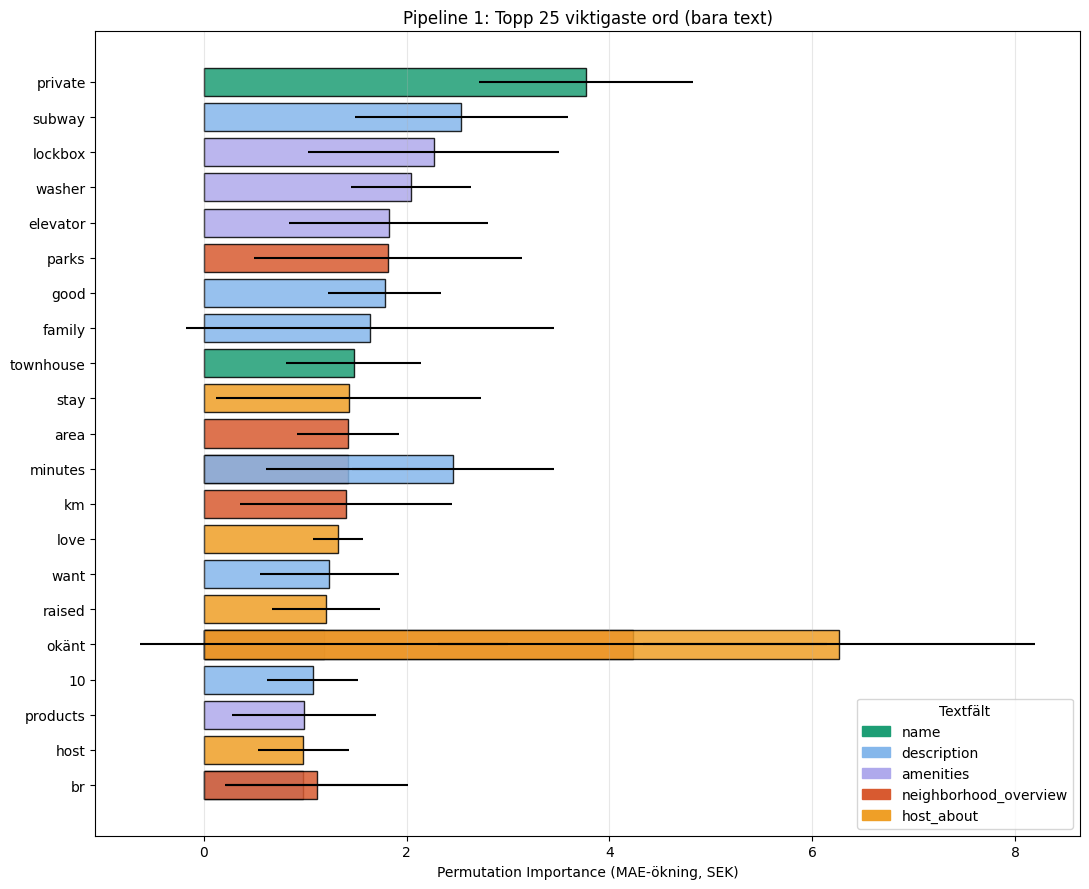

In [10]:
# Färgkoda efter textfält
top_words = fi_text.head(25).iloc[::-1]

color_map_fields = {
    "name":                  "#1D9E75",
    "description":           "#85B7EB",
    "amenities":             "#AFA9EC",
    "neighborhood_overview": "#D85A30",
    "host_about":            "#EF9F27",
}
colors = [color_map_fields[f] for f in top_words["textfält"]]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(top_words["ord"], top_words["importance"],
               xerr=top_words["std"], color=colors, edgecolor="black", alpha=0.85)

ax.set_xlabel("Permutation Importance (MAE-ökning, SEK)")
ax.set_title("Pipeline 1: Topp 25 viktigaste ord (bara text)")
ax.grid(True, alpha=0.3, axis="x")

# Legend
from matplotlib.patches import Patch
legend_items = [Patch(color=c, label=f) for f, c in color_map_fields.items()]
ax.legend(handles=legend_items, loc="lower right", title="Textfält")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Topp 5 ord per textfält — vilka är "guldorden" i varje fält?
# ============================================================
print("\n" + "=" * 60)
print("TOPP 5 ORD PER TEXTFÄLT")
print("=" * 60)

for fält in tfidf_settings.keys():
    sub = fi_text[fi_text["textfält"] == fält].head(5)
    if len(sub) > 0:
        print(f"\n{fält}:")
        for _, row in sub.iterrows():
            print(f"  '{row['ord']}': {row['importance']:.2f} SEK")


TOPP 5 ORD PER TEXTFÄLT

name:
  'private': 3.77 SEK
  'townhouse': 1.48 SEK
  'bathroom': 0.91 SEK
  'kungsholmen': 0.90 SEK
  'södermalm': 0.69 SEK

description:
  'subway': 2.54 SEK
  'minutes': 2.46 SEK
  'good': 1.78 SEK
  'family': 1.64 SEK
  'want': 1.24 SEK

amenities:
  'lockbox': 2.26 SEK
  'washer': 2.04 SEK
  'elevator': 1.82 SEK
  'products': 0.99 SEK
  'wifi': 0.97 SEK

neighborhood_overview:
  'okänt': 4.23 SEK
  'parks': 1.82 SEK
  'area': 1.42 SEK
  'minutes': 1.42 SEK
  'km': 1.40 SEK

host_about:
  'okänt': 6.26 SEK
  'stay': 1.43 SEK
  'love': 1.32 SEK
  'raised': 1.21 SEK
  'host': 0.98 SEK


In [ ]:
"""
Värdet 6.26 SEK för okänt betyder:
Om jag förstör denna feature blir modellen 6.26 SEK sämre.

Det säger inget om dyrt eller billigt.
Permutation importance är som att fråga hur viktig är termometern i bilen? — svaret säger inget om det är varmt eller kallt ute. Bara att informationen är värd att ha.
""

In [13]:
ord_att_testa = [
    ("host_about",            "okänt"),
    ("neighborhood_overview", "okänt"),
    ("name",                  "private"),
    ("amenities",             "lockbox"),
    ("amenities",             "elevator"),
    ("amenities",             "washer"),
    ("description",           "subway"),
    ("description",           "family"),
]

print(f"{'Fält':25s} {'Ord':15s} {'Med':>8s} {'Utan':>8s} {'Diff':>8s}")
print("-" * 70)
for fält, ord in ord_att_testa:
    mask = df[fält].str.lower().str.contains(ord, na=False)
    med  = df.loc[mask, "price"].mean()
    utan = df.loc[~mask, "price"].mean()
    diff = med - utan
    print(f"{fält:25s} {ord:15s} {med:>8.0f} {utan:>8.0f} {diff:>+8.0f}")

Fält                      Ord                  Med     Utan     Diff
----------------------------------------------------------------------
host_about                okänt               1409     1314      +95
neighborhood_overview     okänt               1314     1449     -136
name                      private             1205     1367     -162
amenities                 lockbox             1344     1367      -23
amenities                 elevator            1360     1364       -4
amenities                 washer              1437     1113     +324
description               subway              1317     1377      -59
description               family              1827     1303     +525


In [ ]:
# Utökad pipeline, lägg till numeriska variabler till modellen!

Efter all rensning: 3027 rader kvar
Train: 2421, Test: 606

Bygger TF-IDF-vektorer...
  name                     : 100 features
  description              : 200 features
  amenities                : 100 features
  neighborhood_overview    :  50 features
  host_about               :  50 features

Final feature matrix:
  Train: (2421, 536)
  Numerisk: 32, Kategorisk: 4, Text: 500

Modell — antal parametrar: 79,105
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 1225.7329 - mae: 1225.7329 - val_loss: 797.3957 - val_mae: 797.3957
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 657.1156 - mae: 657.1156 - val_loss: 562.3002 - val_mae: 562.3002
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 502.4936 - mae: 502.4936 - val_loss: 449.4924 - val_mae: 449.4924
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 432.9376 - mae: 432.9376 - val_loss: 417.8290 - val_mae: 417.8290
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 411.1884 - mae: 411.188

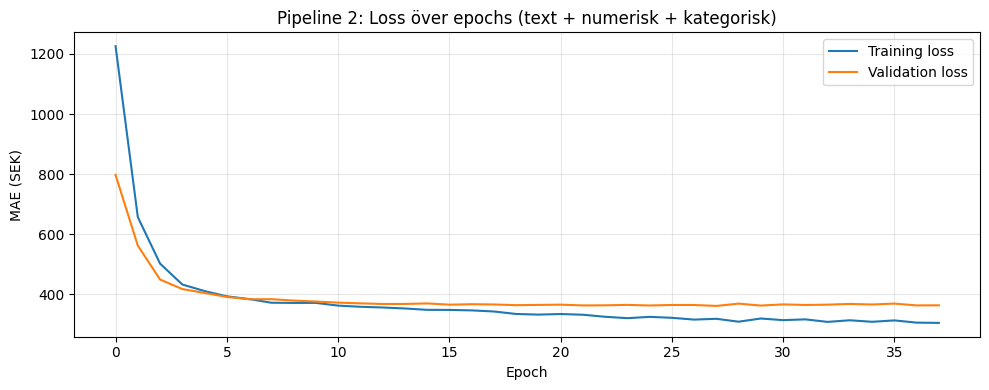

In [3]:
# ============================================================
# PIPELINE 2: TEXT + NUMERISKA + KATEGORISKA
# Återanvänder TF-IDF från Pipeline 1
# Lägger till numeriska och kategoriska features
# ============================================================

from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.sparse import hstack, csr_matrix

# ============================================================
# STEG 1: Definiera kolumngrupper
# ============================================================
cat_cols = ["property_type", "room_type",
            "neighbourhood_cleansed", "host_response_time"]

num_cols = [
    "bedrooms", "bathrooms", "beds", "accommodates",
    "minimum_nights", "maximum_nights",
    "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
    "review_scores_rating", "review_scores_accuracy",
    "review_scores_cleanliness", "review_scores_checkin",
    "review_scores_communication", "review_scores_location",
    "review_scores_value",
    "latitude", "longitude",
    "availability_30", "availability_60",
    "availability_90", "availability_365",
    "host_listings_count", "calculated_host_listings_count",
]

bool_cols = ["host_is_superhost", "host_has_profile_pic",
             "host_identity_verified", "instant_bookable",
             "has_availability"]

# ============================================================
# STEG 2: Procent-strängar och datum
# (df är samma som från Pipeline 1)
# ============================================================
def parse_pct(s):
    return pd.to_numeric(
        s.astype(str).str.rstrip("%").str.strip().replace("", np.nan),
        errors="coerce") / 100

df["host_response_rate"]   = parse_pct(df["host_response_rate"])
df["host_acceptance_rate"] = parse_pct(df["host_acceptance_rate"])
num_cols += ["host_response_rate", "host_acceptance_rate"]

df["host_since"] = pd.to_datetime(df["host_since"], errors="coerce")
df["host_age_days"] = (pd.Timestamp.now() - df["host_since"]).dt.days
num_cols += ["host_age_days"]

# ============================================================
# STEG 3: Booleans → 0/1
# ============================================================
for c in bool_cols:
    df[c] = (df[c].astype(str).str.strip().str.lower() == "t").astype(int)
num_cols += bool_cols

# ============================================================
# STEG 4: Kategoriska → LabelEncode
# ============================================================
encoders = {}
for c in cat_cols:
    df[c] = df[c].fillna("okänt").astype(str)
    le = LabelEncoder()
    df[c + "_enc"] = le.fit_transform(df[c])
    encoders[c] = le

cat_enc_cols = [c + "_enc" for c in cat_cols]

# ============================================================
# STEG 5: Numeriska — tvinga till tal, fyll median
# ============================================================
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

# ============================================================
# STEG 6: Stryp outliers i features
# ============================================================
df = df[df["bedrooms"].between(0, 10)]
df = df[df["bathrooms"].between(0, 10)]
df = df[df["accommodates"].between(1, 20)]
df = df[df["minimum_nights"].between(1, 365)]

print(f"Efter all rensning: {len(df)} rader kvar")

# ============================================================
# STEG 7: Splitta OM (samma random_state = samma split)
# ============================================================
y = df[target].values.astype("float32")

X_train_df, X_test_df, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train_df)}, Test: {len(X_test_df)}")

# ============================================================
# STEG 8: Bygg om TF-IDF (nya rader = nytt vokabulär)
# ============================================================
print("\nBygger TF-IDF-vektorer...")

tfidf_train = []
tfidf_test = []

for col, max_feat in tfidf_settings.items():
    tfidf = TfidfVectorizer(
        max_features=max_feat,
        stop_words="english",
        lowercase=True,
        min_df=5,
        ngram_range=(1, 1))
    
    train_vec = tfidf.fit_transform(X_train_df[col].values)
    test_vec  = tfidf.transform(X_test_df[col].values)
    
    tfidf_train.append(train_vec)
    tfidf_test.append(test_vec)
    print(f"  {col:25s}: {train_vec.shape[1]:>3} features")

# ============================================================
# STEG 9: Skala numeriska
# ============================================================
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train_df[num_cols]).astype("float32")
X_test_num  = scaler.transform(X_test_df[num_cols]).astype("float32")

# ============================================================
# STEG 10: Kombinera ALLT till en matris
# ============================================================
X_train_num_sp = csr_matrix(X_train_num)
X_test_num_sp  = csr_matrix(X_test_num)

X_train_cat_sp = csr_matrix(X_train_df[cat_enc_cols].values.astype("float32"))
X_test_cat_sp  = csr_matrix(X_test_df[cat_enc_cols].values.astype("float32"))

X_train_full = hstack([X_train_num_sp, X_train_cat_sp] + tfidf_train).toarray().astype("float32")
X_test_full  = hstack([X_test_num_sp,  X_test_cat_sp]  + tfidf_test).toarray().astype("float32")

print(f"\nFinal feature matrix:")
print(f"  Train: {X_train_full.shape}")
print(f"  Numerisk: {len(num_cols)}, Kategorisk: {len(cat_enc_cols)}, Text: {sum(t.shape[1] for t in tfidf_train)}")

# ============================================================
# STEG 11: Bygg samma Sequential modell
# ============================================================
model_full = tf.keras.models.Sequential([
    tf.keras.Input(shape=(X_train_full.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_full.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"])

print(f"\nModell — antal parametrar: {model_full.count_params():,}")

# ============================================================
# STEG 12: Träna
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True)

history_full = model_full.fit(
    X_train_full, y_train,
    validation_data=(X_test_full, y_test),
    epochs=100, batch_size=32,
    callbacks=[early_stop],
    verbose=1)

# ============================================================
# STEG 13: Utvärdera
# ============================================================
y_pred_full = model_full.predict(X_test_full).flatten()
mae_full = np.mean(np.abs(y_pred_full - y_test))
rmse_full = np.sqrt(np.mean((y_pred_full - y_test) ** 2))

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

print("\n" + "=" * 50)
print("PIPELINE 2 — ALLT TILLSAMMANS")
print("=" * 50)
print(f"Antal features:                  {X_train_full.shape[1]}")
print(f"  varav numeriska:               {len(num_cols)}")
print(f"  varav kategoriska:             {len(cat_enc_cols)}")
print(f"  varav text (TF-IDF):           {sum(t.shape[1] for t in tfidf_train)}")
print(f"")
print(f"MAE 'gissa medel':               {mae_base:.1f} SEK")
print(f"MAE pipeline 1 (bara text):      442.4 SEK")
print(f"MAE pipeline 2 (allt):           {mae_full:.1f} SEK")
print(f"RMSE:                            {rmse_full:.1f} SEK")
print(f"Relativt fel:                    {mae_full/y_test.mean()*100:.1f}%")

# ============================================================
# STEG 14: Plotta loss
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history_full.history["loss"], label="Training loss")
plt.plot(history_full.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Pipeline 2: Loss över epochs (text + numerisk + kategorisk)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# PERMUTATION IMPORTANCE — Pipeline 2 (allt)
# Använder exakt samma teknik som kursen (KerasModelWrapper)
# Modifierad för regression istället för klassificering
# ============================================================

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance

# ============================================================
# Wrapper-klass (samma struktur som kursen, men för regression)
# ============================================================
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    # I kursen var det ClassifierMixin — för regression använder vi RegressorMixin
    
    def __init__(self, keras_model):
        self.keras_model = keras_model
    
    def fit(self, X, y):
        # Modellen är redan tränad
        pass
    
    def predict(self, X):
        # Returnera kontinuerligt värde direkt (ingen argmax)
        return self.keras_model.predict(X, verbose=0).flatten()

# ============================================================
# Sätt upp permutation importance
# ============================================================
wrapped_model = KerasRegressorWrapper(model_full)

print("Kör permutation importance (kan ta några minuter)...")
result = permutation_importance(
    wrapped_model, X_test_full, y_test,
    scoring="neg_mean_absolute_error",   # för regression
    n_repeats=10,
    random_state=42)

# ============================================================
# Sammanställ feature-namn (samma ordning som i matrisen)
# ============================================================
# Ordning i X_train_full: [numeric, cat, tfidf...]
feature_names = (
    num_cols +                                    # 32 numeriska
    cat_enc_cols +                                # 4 kategoriska
    list(tfidf_vectorizers["name"].get_feature_names_out()) +
    list(tfidf_vectorizers["description"].get_feature_names_out()) +
    list(tfidf_vectorizers["amenities"].get_feature_names_out()) +
    list(tfidf_vectorizers["neighborhood_overview"].get_feature_names_out()) +
    list(tfidf_vectorizers["host_about"].get_feature_names_out())
)

# Prefixa text-features för att göra dem distinkta
text_field_offsets = []
offset = len(num_cols) + len(cat_enc_cols)
for col in tfidf_settings.keys():
    n_features = tfidf_vectorizers[col].get_feature_names_out().shape[0]
    text_field_offsets.append((col, offset, offset + n_features))
    offset += n_features

# Skapa kategori-etikett per feature
def get_category(idx):
    if idx < len(num_cols):
        return "Numerisk"
    elif idx < len(num_cols) + len(cat_enc_cols):
        return "Kategorisk"
    else:
        for col, start, end in text_field_offsets:
            if start <= idx < end:
                return f"Text ({col})"
    return "Okänd"

# ============================================================
# Bygg DataFrame
# ============================================================
fi_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": result.importances_mean,
    "std":        result.importances_std,
    "kategori":   [get_category(i) for i in range(len(feature_names))],
})

# Sortera efter importance (störst först)
fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("TOPP 20 FEATURES")
print("=" * 60)
print(fi_df.head(20).to_string(index=False))

Kör permutation importance (kan ta några minuter)...

TOPP 20 FEATURES
                       feature  importance      std                     kategori
                  accommodates   65.574036 6.330381                     Numerisk
                      bedrooms   55.259418 6.053522                     Numerisk
                     longitude   36.815085 4.010968                     Numerisk
                 room_type_enc   34.400116 7.447595                   Kategorisk
                minimum_nights   19.177130 2.848912                     Numerisk
                      latitude   17.793530 4.038655                     Numerisk
        review_scores_location   14.200922 2.797867                     Numerisk
                           och   12.714142 2.116418            Text (host_about)
               availability_30   12.076639 2.199191                     Numerisk
           review_scores_value   12.058032 2.715126                     Numerisk
             reviews_per_month   10.74

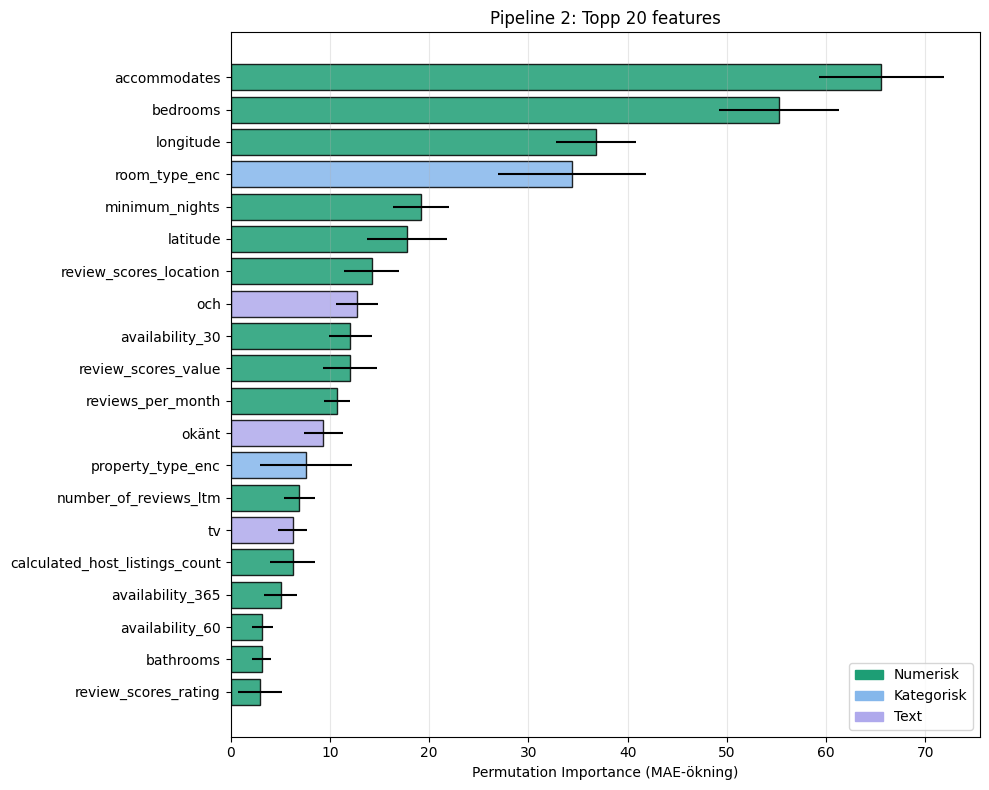

In [7]:
# Topp 20
top = fi_df.head(20).iloc[::-1]  # vänd för plot

# Färgkoda efter kategori
def short_cat(c):
    if c.startswith("Text"): return "Text"
    return c

top["short_kat"] = top["kategori"].apply(short_cat)

color_map = {"Numerisk": "#1D9E75", "Kategorisk": "#85B7EB", "Text": "#AFA9EC"}
colors = [color_map[c] for c in top["short_kat"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top["feature"], top["importance"],
               xerr=top["std"], color=colors, edgecolor="black", alpha=0.85)

ax.set_xlabel("Permutation Importance (MAE-ökning)")
ax.set_title("Pipeline 2: Topp 20 features")
ax.grid(True, alpha=0.3, axis="x")

# Legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=t) for t, c in color_map.items()]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.show()

In [8]:
# Summera per kategori
fi_df["kategori_grov"] = fi_df["kategori"].apply(short_cat)
summary = fi_df.groupby("kategori_grov")["importance"].agg(
    ["sum", "mean", "count"]
).sort_values("sum", ascending=False)

print("\n" + "=" * 50)
print("SUMMERAT PER KATEGORI")
print("=" * 50)
print(summary)

# Andel av total importance
total = fi_df["importance"].sum()
summary["andel_%"] = (summary["sum"] / total * 100).round(1)
print(f"\nAndel av total importance:")
print(summary[["sum", "andel_%"]])


SUMMERAT PER KATEGORI
                      sum       mean  count
kategori_grov                              
Numerisk       286.551953   8.954749     32
Text            65.513919   0.131028    500
Kategorisk      44.332721  11.083180      4

Andel av total importance:
                      sum  andel_%
kategori_grov                     
Numerisk       286.551953     72.3
Text            65.513919     16.5
Kategorisk      44.332721     11.2


In [ ]:
# Kan vi ytterligare förbättra resultatet med Grid Search?

# ============================================================
# KERAS TUNER GRID SEARCH — Pipeline 2
# Hittar bästa hyperparametrarna för vår modell
# Följer kursens struktur från sid 18-20
# ============================================================

import keras_tuner as kt
import tensorflow as tf

# ============================================================
# STEG 1: Definiera build_model med hyperparametrar
# ============================================================
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X_train_full.shape[1],)),
        
        # Första dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer1", [64, 128, 256]),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_rate_layer1", [0.2, 0.3, 0.4])
        ),
        
        # Andra dolda lagret
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer2", [32, 64, 128]),
            activation=hp.Choice("activation_layer2", ["relu", "tanh"])
        ),
        tf.keras.layers.Dropout(
            hp.Choice("dropout_rate_layer2", [0.2, 0.3, 0.4])
        ),
        
        # Tredje dolda lagret (mindre)
        tf.keras.layers.Dense(
            units=hp.Choice("n_neurons_layer3", [16, 32, 64]),
            activation="relu"
        ),
        
        # Output: 1 neuron, linjär (regression)
        tf.keras.layers.Dense(1)
    ])
    
    # Optimerare med olika learning rates
    learning_rate = hp.Choice("learning_rate", [0.001, 0.0005, 0.0001])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss="mae",
        metrics=["mae"]
    )
    return model

# ============================================================
# STEG 2: Skapa GridSearch Tuner
# ============================================================
tuner = kt.GridSearch(
    hypermodel=build_model,
    objective="val_mae",            # vi minimerar val_mae för regression
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_airbnb",
    project_name="grid_search_pipeline2"
)

# Visa sökrymden
tuner.search_space_summary()

# ============================================================
# STEG 3: Kör grid search
# OBS: detta tar tid! 3*3*3*3*3*3 = 729 kombinationer
# Vi minskar genom att låta EarlyStopping stoppa dåliga försök
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

print("\nStartar Grid Search... (tar några minuter)")
tuner.search(
    X_train_full, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1  # tysta om vi vill med 0 så vi inte drunknar i output
)

# ============================================================
# STEG 4: Hämta bästa hyperparametrarna
# ============================================================
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "=" * 60)
print("BÄSTA HYPERPARAMETRAR FUNNA")
print("=" * 60)
print(f"  Neuroner lager 1:        {best_hps.get('n_neurons_layer1')}")
print(f"  Aktivering lager 1:      {best_hps.get('activation')}")
print(f"  Dropout lager 1:         {best_hps.get('dropout_rate_layer1')}")
print(f"  Neuroner lager 2:        {best_hps.get('n_neurons_layer2')}")
print(f"  Aktivering lager 2:      {best_hps.get('activation_layer2')}")
print(f"  Dropout lager 2:         {best_hps.get('dropout_rate_layer2')}")
print(f"  Neuroner lager 3:        {best_hps.get('n_neurons_layer3')}")
print(f"  Learning rate:           {best_hps.get('learning_rate')}")

# ============================================================
# STEG 5: Bygg den bästa modellen och träna ordentligt
# ============================================================
best_model = build_model(best_hps)

print(f"\nBästa modell — antal parametrar: {best_model.count_params():,}")

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)

print("\nTränar bästa modellen i 100 epochs...")
history_best = best_model.fit(
    X_train_full, y_train,
    validation_data=(X_test_full, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_final],
    verbose=1
)

# ============================================================
# STEG 6: Utvärdera bästa modellen
# ============================================================
y_pred_best = best_model.predict(X_test_full).flatten()
mae_best = np.mean(np.abs(y_pred_best - y_test))
rmse_best = np.sqrt(np.mean((y_pred_best - y_test) ** 2))

mean_pred = y_train.mean()
mae_base = np.mean(np.abs(y_test - mean_pred))

print("\n" + "=" * 60)
print("BÄSTA MODELLEN — RESULTAT")
print("=" * 60)
print(f"MAE 'gissa medel':         {mae_base:.1f} SEK")
print(f"MAE pipeline 1 (text):     442.4 SEK")
print(f"MAE pipeline 2 (allt):     361.7 SEK")
print(f"MAE bästa modell:          {mae_best:.1f} SEK   ← ny")
print(f"RMSE:                      {rmse_best:.1f} SEK")
print(f"Relativt fel:              {mae_best/y_test.mean()*100:.1f}%")

# ============================================================
# STEG 7: Spara bästa modellen
# ============================================================
best_model.save("best_airbnb_model.h5")
print("\nBästa modellen sparad som best_airbnb_model.h5")

# ============================================================
# STEG 8: Plotta loss-kurvan
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_best.history["loss"], label="Training loss")
plt.plot(history_best.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (SEK)")
plt.title("Bästa modellen: Loss över epochs")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_best, alpha=0.4, s=10)
mx = max(y_test.max(), y_pred_best.max())
plt.plot([0, mx], [0, mx], "r--", linewidth=1)
plt.xlabel("Faktiskt pris (SEK)")
plt.ylabel("Förutsagt pris (SEK)")
plt.title(f"Predictions vs sanning — MAE {mae_best:.0f} SEK")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Trial 5 Complete [00h 00m 15s]
val_mae: 368.5742492675781

Best val_mae So Far: 348.0166931152344
Total elapsed time: 00h 01m 14s

Search: Running Trial #6

Value             |Best Value So Far |Hyperparameter
64                |64                |n_neurons_layer1
relu              |relu              |activation
0.2               |0.2               |dropout_rate_layer1
32                |32                |n_neurons_layer2
relu              |relu              |activation_layer2
0.2               |0.2               |dropout_rate_layer2
32                |16                |n_neurons_layer3
0.0001            |0.001             |learning_rate

Epoch 1/30
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1365.5352 - mae: 1365.5352 - val_loss: 1340.9729 - val_mae: 1340.9729
Epoch 2/30
19/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1382.2982 - mae: 1382.2982 